## **Graph 1**
**Comparing the running time with the size of N for POSIX, OpenMP, Open MPI Block-Cyclic, Open MPI Cyclic.**

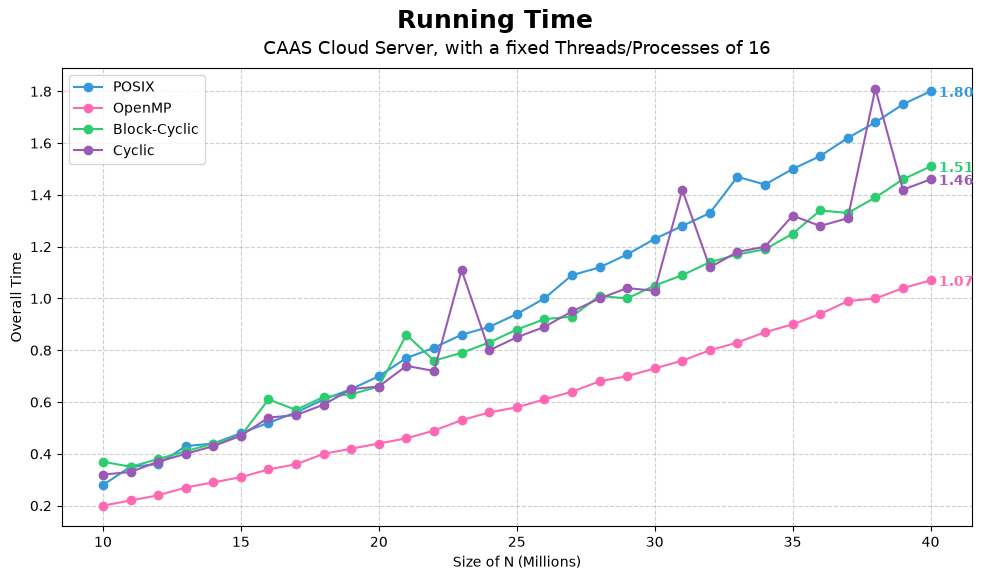

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "RunningTimeRecording.xlsx"
df = pd.read_excel(file_name, sheet_name="CAAS", header=[1, 2])

# Clean up 'N' column: convert to numeric
n_col = df.columns[0]
df[n_col] = pd.to_numeric(df[n_col], errors='coerce')

# Drop NaN values and filter out small/summary N values
df = df.dropna(subset=[n_col])
df = df[df[n_col] >= 10000] 
df = df.sort_values(by=n_col).reset_index(drop=True)

# Convert N values to Millions for the X-axis
x_values = df[n_col] / 1000000

# Removed 'Serial Code' from categories
categories = {
    'POSIX (Threads = 16)': 'POSIX',
    'OpenMP (Threads = 16)': 'OpenMP',
    'Open MPI Block-Cyclic (Processes = 16)': 'Block-Cyclic',
    'Open MPI Cyclic (Processes = 16)': 'Cyclic'
}

# 2. Setup the plot
plt.figure(figsize=(10, 6))

# Updated colors: Light Blue, Pink, Light Green, Light Purple (vibrant, not too pale)
colors = ['#3498DB', '#FF69B4', '#2ECC71', '#9B59B6']

# 3. Extract, convert to numeric, round, and plot each line
for idx, (excel_col, legend_label) in enumerate(categories.items()):
    col_tuple = [col for col in df.columns if isinstance(col[0], str) and excel_col in col[0] and col[1] == 'Overall']
    
    if col_tuple:
        target_col = col_tuple[0]
        
        # Convert to numeric to fix the rounding error on string artifacts
        df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
        
        # Extract the values and round overall time to two decimal places
        y_values = df[target_col].round(2)
        
        # Plot the line with dot points
        plt.plot(x_values, y_values, marker='o', label=legend_label, color=colors[idx])
        
        # Annotate the last dot point with its value
        last_x = x_values.iloc[-1]
        last_y = y_values.iloc[-1]
        
        plt.annotate(f'{last_y:.2f}', 
                     xy=(last_x, last_y), 
                     xytext=(6, -4), # Offset slightly to the right
                     textcoords='offset points',
                     color=colors[idx], 
                     fontweight='bold')

# Formatting Titles (Increased font sizes)
plt.suptitle("Running Time with Size of N", fontweight='bold', fontsize=18, y=0.96)
plt.title("CAAS Cloud Server, with a fixed Threads/Processes of 16", fontsize=13, pad=10)

# Axis labels and legend (Renamed X-axis)
plt.xlabel("Size of N (Millions)")
plt.ylabel("Overall Time")
plt.legend()

# Set X-axis ticks exactly to 10, 15, 20, 25, 30, 35, 40
plt.xticks(range(10, 41, 5))

# Display grid and show plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## **Graph 2**
**Comparing the empirical speedup with the size of N for POSIX, OpenMP, Open MPI Block-Cyclic, Open MPI Cyclic.**

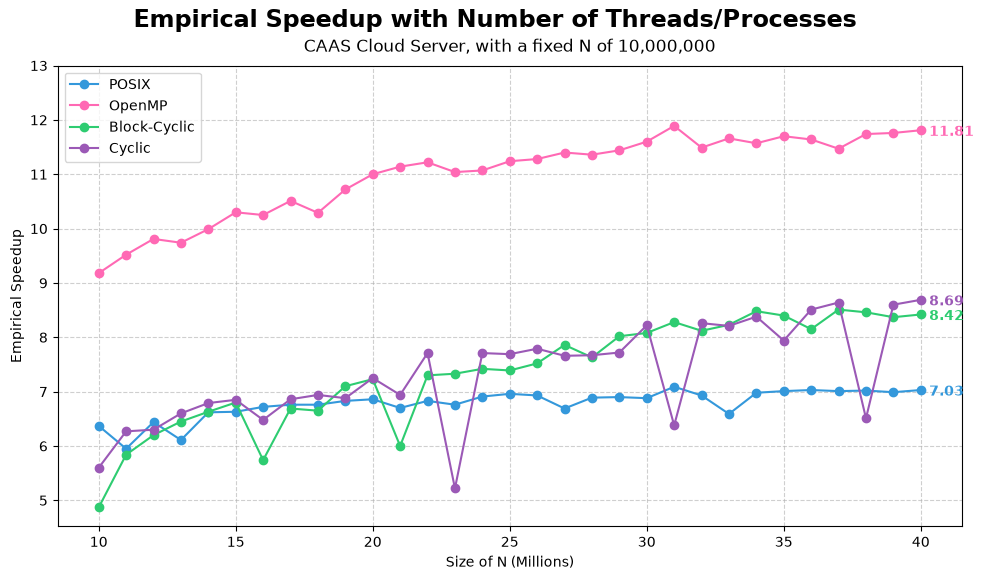

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Access the specific worksheet
file_name = "RunningTimeRecording.xlsx"
df = pd.read_excel(file_name, sheet_name="CAAS", header=[1, 2])

# Clean up 'N' column: convert to numeric
n_col = df.columns[0]
df[n_col] = pd.to_numeric(df[n_col], errors='coerce')

# Drop NaN values and filter out small/summary N values
df = df.dropna(subset=[n_col])
df = df[df[n_col] >= 10000] 
df = df.sort_values(by=n_col).reset_index(drop=True)

# Convert N values to Millions for the X-axis
x_values = df[n_col] / 1000000

# Categories for Empirical Speedup
categories = {
    'POSIX (Threads = 16)': 'POSIX',
    'OpenMP (Threads = 16)': 'OpenMP',
    'Open MPI Block-Cyclic (Processes = 16)': 'Block-Cyclic',
    'Open MPI Cyclic (Processes = 16)': 'Cyclic'
}

# 2. Setup the plot
plt.figure(figsize=(10, 6))

# Colors: Light Blue, Pink, Light Green, Light Purple
colors = ['#3498DB', '#FF69B4', '#2ECC71', '#9B59B6']

# 3. Extract, convert to numeric, round, and plot each line
for idx, (excel_col, legend_label) in enumerate(categories.items()):
    # Find the matching column for the current category and its 'E Speedup' sub-column
    col_tuple = [col for col in df.columns if isinstance(col[0], str) and excel_col in col[0] and 'E Speedup' in str(col[1])]
    
    if col_tuple:
        target_col = col_tuple[0]
        
        # Convert to numeric to fix the rounding error on string artifacts
        df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
        
        # Extract the values and round empirical speedup to two decimal places
        y_values = df[target_col].round(2)
        
        # Plot the line with dot points
        plt.plot(x_values, y_values, marker='o', label=legend_label, color=colors[idx])
        
        # Annotate the last dot point with its value
        last_x = x_values.iloc[-1]
        last_y = y_values.iloc[-1]
        
        plt.annotate(f'{last_y:.2f}', 
                     xy=(last_x, last_y), 
                     xytext=(6, -4), # Offset slightly to the right
                     textcoords='offset points',
                     color=colors[idx], 
                     fontweight='bold')

# Formatting Titles
plt.suptitle("Empirical Speedup with Number of Threads/Processes", fontweight='bold', fontsize=17, y=0.96)
plt.title("CAAS Cloud Server, with a fixed N of 10,000,000", fontsize=12, pad=10)

# Axis labels and legend
plt.xlabel("Size of N (Millions)")
plt.ylabel("Empirical Speedup")
plt.legend()

# Set X-axis ticks exactly to 10, 15, 20, 25, 30, 35, 40
plt.xticks(range(10, 41, 5))

# Set Y-axis limit so the max is 12 (starts at 0 by default, adjusting top only)
plt.ylim(top=13)

# Display grid and show plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()